## Example 5: Sparse Randomly Chosen Reactions from 4D System

In [1]:
import sys
import os

# Add repo root to Python path (one level up from examples/)
sys.path.append(os.path.abspath(".."))  

from src.parsing import *
from src.inference import *
from src.mcmc import *
from CRN_Simulation.CRN import CRN

import numpy as np
import random

In [2]:
# Potentially make something that would generate all the complexes and such.
# Could generalize more.

# Define species names
species_names = ["A", "B", "X","Y"]

# Define complexes — dimension is (# species) x (# complexes)
# Each column is a complex: [A, B, X, Y]
complexes = np.array([
    # 0   A   B   X   Y  2A  2B  2X  2Y  A+B A+X A+Y B+X B+Y X+Y
    [  0,  1,  0,  0,  0,  2,  0,  0,  0,  1,  1,  1,  0,  0,  0],  # A
    [  0,  0,  1,  0,  0,  0,  2,  0,  0,  1,  0,  0,  1,  1,  0],  # B
    [  0,  0,  0,  1,  0,  0,  0,  2,  0,  0,  1,  0,  1,  0,  1],  # X
    [  0,  0,  0,  0,  1,  0,  0,  0,  2,  0,  0,  1,  0,  1,  1],  # Y
])

# Create Reactant, Product, Stochiometric Matrix, Define Compatible Reactions and Everything Needed for CRN
reactant_matrix, product_matrix, stoichiometric_matrix, reaction_names, parameter_names, unique_changes, compatible_reactions = generate_reactions(complexes, species_names)

# Plot some output to the screen
print(f"Total reactions generated: {len(reaction_names)}")
max_show = 3
print("Some Reaction Names:", reaction_names[:max_show])

print("\nStoichiometric Changes (Grouped by Unique ΔX):")
print("------------------------------------------------")

count_shown = 0

for deltaX in unique_changes:            # <-- ordered, stable, consistent
    rxn_indices = compatible_reactions[deltaX]
    deltaX_clean = tuple(int(x) for x in deltaX)

    # Only show groups with >1 reaction if desired
    # Remove this if you want *all* ΔX shown
    if len(rxn_indices) <= 1:
        continue

    # Collect human-readable reaction names
    rxn_names = [reaction_names[i] for i in rxn_indices]

    print(f"ΔX = {deltaX_clean}")
    print(f"  Reaction indices: {rxn_indices}")
    print("  Reactions:")
    for idx, rname in zip(rxn_indices, rxn_names):
        print(f"    {idx}: {rname}")
    print()

    count_shown += 1
    if count_shown >= max_show:
        break

Total reactions generated: 210
Some Reaction Names: ['Empty_to_A:', 'Empty_to_B:', 'Empty_to_X:']

Stoichiometric Changes (Grouped by Unique ΔX):
------------------------------------------------
ΔX = (1, 0, 0, 0)
  Reaction indices: [0, 18, 36, 51, 66]
  Reactions:
    0: Empty_to_A:
    18: A_to_2A:
    36: B_to_A+B:
    51: X_to_A+X:
    66: Y_to_A+Y:

ΔX = (0, 1, 0, 0)
  Reaction indices: [1, 22, 33, 53, 68]
  Reactions:
    1: Empty_to_B:
    22: A_to_A+B:
    33: B_to_2B:
    53: X_to_B+X:
    68: Y_to_B+Y:

ΔX = (0, 0, 1, 0)
  Reaction indices: [2, 23, 39, 48, 69]
  Reactions:
    2: Empty_to_X:
    23: A_to_A+X:
    39: B_to_B+X:
    48: X_to_2X:
    69: Y_to_X+Y:



In [3]:
# Number of Reactions to Sample and Gamma Prior
N = 20
alpha, beta = 2.6, 0.4

(CRN_stoichiometric_matrix, CRN_reaction_names, CRN_parameter_names,
 CRN_propensities, trueTheta, parameter_values, sampled_indices) = build_CRN_bySamplingReactions_withConstraints(
        reactant_matrix, product_matrix, stoichiometric_matrix,
        reaction_names, parameter_names, species_names,
        unique_changes, compatible_reactions,
        N=20, n_ambiguous_changes=4, min_reactions_per_change=2,
        alpha=2.6, beta=0.4, seed=19, verbose=True)

# Create Reaction Network with CRN_Simulation.CRN
reactionNetwork = CRN(species_names=species_names,
         stoichiometric_matrix=CRN_stoichiometric_matrix,
         parameters_names=CRN_parameter_names,
         reaction_names=CRN_reaction_names,
         propensities=CRN_propensities)

# Save Reaction Network for Additional Analysis if Needed
save_reaction_network(
    species_names, reactant_matrix,
    CRN_stoichiometric_matrix, CRN_reaction_names, CRN_parameter_names,
    trueTheta, parameter_values, sampled_indices,
    unique_changes, compatible_reactions,
    filename="../data/example5_network.json"
)


[Constraint] Guaranteeing 4 ambiguous stoichiometric changes:
  ΔX=(0, 1, 0, 0)  →  5 compatible reactions available
  ΔX=(0, 0, 0, -1)  →  5 compatible reactions available
  ΔX=(0, 0, 0, 1)  →  5 compatible reactions available
  ΔX=(0, 1, 0, -1)  →  5 compatible reactions available
  Guaranteed reaction indices (8 total): [22, 53, 155, 199, 63, 24, 208, 163]
  Filler reactions sampled: 12
  Total sampled: 20

Sampling 20 reactions out of 210 total.

Index  Param    Reaction Name                  Value    Guaranteed
-----------------------------------------------------------------
22     k22      A_to_A+B:                      1.046    ✓
53     k53      X_to_B+X:                      0.717    ✓
155    k155     A+Y_to_A:                      0.590    ✓
199    k199     X+Y_to_X:                      0.768    ✓
63     k63      Y_to_2Y:                       1.067    ✓
24     k24      A_to_A+Y:                      0.280    ✓
208    k208     X+Y_to_B+X:                    0.906    ✓
163  

Initial state: {'A': 5, 'B': 5, 'X': 5, 'Y': 5}
Initial state: {'A': 5, 'B': 5, 'X': 5, 'Y': 5}
Initial state: {'A': 5, 'B': 5, 'X': 5, 'Y': 5}
Trajectory saved to ../data/example5_T100_trajectory.json
Trajectory saved to ../data/example5_T200_trajectory.json
Trajectory saved to ../data/example5_T400_trajectory.json


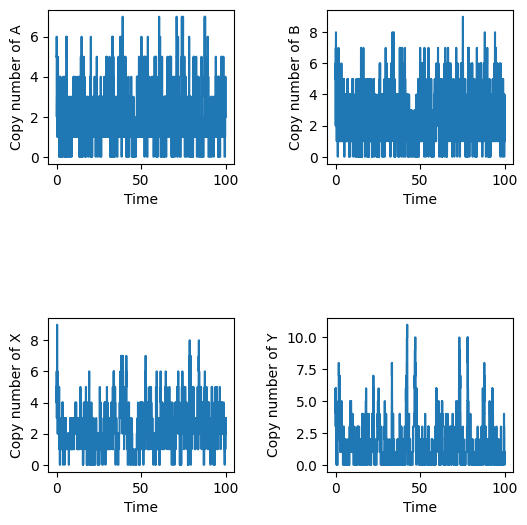

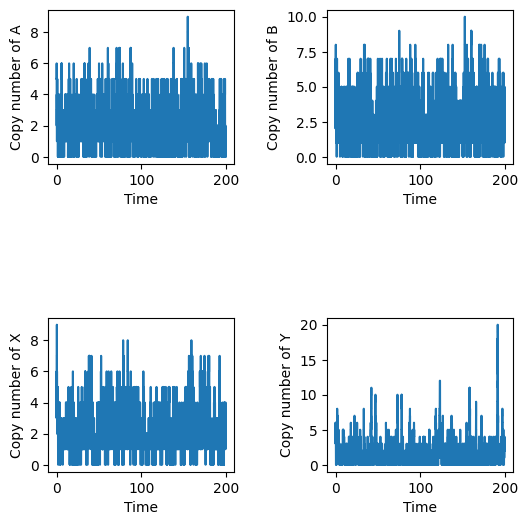

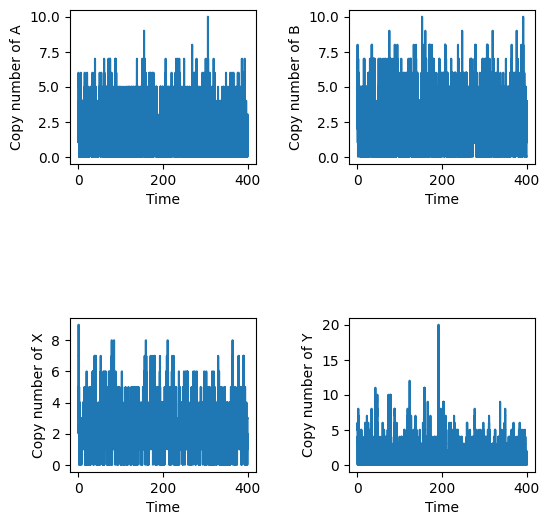

In [4]:
data_dir = "../data"  # relative to examples/ folder
os.makedirs(data_dir, exist_ok=True)

Tfinal1 = 100
Tfinal2 = 200
Tfinal3 = 400

# Generate trajectory (T = 100)
time_list1, state_list1 = generate_single_trajectory(
    reactionNetwork,
    parameter_values,
    species_names,
    finalTime=Tfinal1,   # adjust as needed
    minVal=5,
    maxVal=5,
    seed=42          # for reproducibility
)

# Generate trajectory (T = 200)
time_list2, state_list2 = generate_single_trajectory(
    reactionNetwork,
    parameter_values,
    species_names,
    finalTime=Tfinal2,   # adjust as needed
    minVal=5,
    maxVal=5,
    seed=42          # for reproducibility
)

# Generate trajectory (T = 400)
time_list3, state_list3 = generate_single_trajectory(
    reactionNetwork,
    parameter_values,
    species_names,
    finalTime=Tfinal3,   # adjust as needed
    minVal=5,
    maxVal=5,
    seed=42          # for reproducibility
)

# Save trajectory to JSON
trajectory_file = os.path.join(data_dir, "example5_T100_trajectory.json")
save_trajectory(time_list1, state_list1, filename=trajectory_file)

# Save trajectory to JSON
trajectory_file = os.path.join(data_dir, "example5_T200_trajectory.json")
save_trajectory(time_list2, state_list2, filename=trajectory_file)

# Save trajectory to JSON
trajectory_file = os.path.join(data_dir, "example5_T400_trajectory.json")
save_trajectory(time_list3, state_list3, filename=trajectory_file)

In [7]:
import subprocess
subprocess.run(["pip", "install", "openpyxl", "--break-system-packages"], check=True)

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]


CompletedProcess(args=['pip', 'install', 'openpyxl', '--break-system-packages'], returncode=0)

## Parsing Trajectory 1 (TFinal = 100)

Parsing Trajectory
Tracking 130 unique stoichiometric changes.
Trajectory length: 4151 timepoints. Iterating to len-2 to avoid final non-jump.
Finished parsing trajectory. Observed 1176 unique states.
---------
Finished parsing trajectories. Summary:
Trajectory 1: 1176 unique states observed


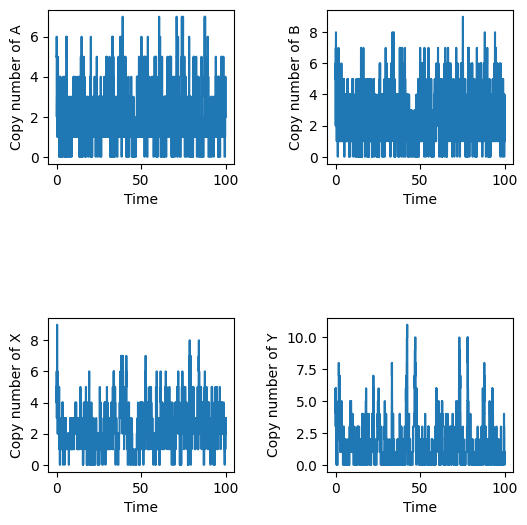

In [5]:
trajectory_file_new = "../data/example5_T100_trajectory.json"
time_list_new, state_list_new = load_trajectory(trajectory_file_new)
reactionNetwork.plot_trajectories(time_list_new, state_list_new)

time_list = time_list_new
state_list = state_list_new

# Parse trajectories for CRN1
print("Parsing Trajectory")
unique_states, jump_counts, waiting_times, propensities = parse_trajectory(
    state_list,time_list,reactant_matrix,unique_changes,compatible_reactions,verbose=True)
print("---------")

# Print basic summary
print("Finished parsing trajectories. Summary:")
print(f"Trajectory 1: {len(unique_states)} unique states observed")

In [8]:
# Ensure the results directory exists
results_dir = "../results/example5_T100"
os.makedirs(results_dir, exist_ok=True)

## Debugging Parameters
runOnlyHigherDim        = False   # Only try to run cases that have >=2 variables
runOnlyOneHigherDimCase = False  # Only run one case with >=2 variables for debugging

## MCMC parameters
NIterates = 500_000
Burnin    = 50_000
Thinout   = 100

# Loop over all unique stoichiometric changes
for index, deltaX in enumerate(unique_changes):
    
    print(f"\nProcessing Index: {index}, Stoichiometric Change: {deltaX}")

    # Extract local data for this stoichiometric change
    (local_counts, local_waiting_times, local_propensities, selected_deltaX) = extract_local_data(
        jump_counts, waiting_times, propensities, unique_changes, 
        index=index, deltaX=deltaX, verbose=True
    )

    # Extract local true theta
    localTheta = trueTheta[compatible_reactions[selected_deltaX]]
    num_reactions = len(localTheta)

    # Skip low-dimensional cases if debugging
    if num_reactions < 2 and runOnlyHigherDim:
        print(f"🚫 Index {index} skipped: only {num_reactions} reaction(s) — needs at least 2 to run MCMC.")
        continue

    # Compute 2-norm
    norm_theta = np.linalg.norm(localTheta, ord=2)
    print(f"Local True Theta: {localTheta} (Norm: {norm_theta:.4f})")

    # Compute likelihood for true theta
    likeTrue = local_log_likelihood(local_counts, local_waiting_times, local_propensities, localTheta)
    print(f"True Likelihood = {likeTrue}")

    total_count = sum(local_counts.values())
    print(f"Total Count = {total_count}")

    # Initialize theta for MCMC
    a, b = 0.001, 2.0
    theta_init = np.random.uniform(a, b, size=localTheta.shape)
    likeInit = local_log_likelihood(local_counts, local_waiting_times, local_propensities, theta_init)

    # Run adaptive MCMC only if norm is significant
    if norm_theta > 0.01:
        print(f"Running Adaptive MCMC with spike-and-slab prior...")
        
        filtered_reactions = [reaction_names[i] for i in compatible_reactions[selected_deltaX]]
        print(f"Reaction Names = {filtered_reactions}")

        AdaptiveThetaChain = adaptive_mcmc_spike_slab(
            local_counts, local_waiting_times, local_propensities,
            theta_init, trueTheta, num_iterations=NIterates,
            alpha=2, beta=0.25, pi=0.75, burn_in=Burnin, adapt_every_n=10,
            printEveryNSteps = 1000
        )

        # Define filenames
        filenameKDE = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_kde.png")
        filenameChain = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_chain.png")
        filenamePosterior = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_posterior.png")

        # Plotting
        plot_mcmc_samples(AdaptiveThetaChain, localTheta, epsilon=1e-5, burnin=Burnin, thinout=Thinout, filename=filenameKDE)
        plot_mcmc_chain(AdaptiveThetaChain, filename=filenameChain)
        if num_reactions >= 2:
            calc_network_posteriors(AdaptiveThetaChain, epsilon=1e-5, prob_cutoff=0.05, burnin=Burnin, thinout=Thinout)
            plot_network_and_parameter_posteriors(AdaptiveThetaChain, localTheta, epsilon=1e-5,
                                                 prob_cutoff=0.05, burnin=Burnin, thinout=Thinout, filename=filenamePosterior)

        # Summary statistics to Excel
        chains = [AdaptiveThetaChain]
        labels = ["Adaptive Spike & Slab"]
        summarize_chains(chains, localTheta, labels,
                         results_dir=results_dir, filename="mcmc_summary.xlsx",
                         burnin=Burnin, thinout=Thinout, alpha_ci=0.05, epsilon=1e-3,
                         run_index=index, count=total_count)

        print(f"MCMC completed for index {index}.")

        if (num_reactions > 1) and runOnlyOneHigherDimCase:
            break

    else:
        print(f"Skipping MCMC for index {index}: norm too small ({norm_theta:.4f}).")

    print("**********")



Processing Index: 0, Stoichiometric Change: (1, 0, 0, 0)
Extracting local data for stoichiometric change [1, 0, 0, 0] at index 0
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 1176 states processed.
Local True Theta: [0.         1.51680738 0.         0.         0.        ] (Norm: 1.5168)
True Likelihood = 48.47584421026841
Total Count = 255
Running Adaptive MCMC with spike-and-slab prior...
Reaction Names = ['Empty_to_A:', 'A_to_2A:', 'B_to_A+B:', 'X_to_A+X:', 'Y_to_A+Y:']
Iteration 1000: Accept Rate = 0.652, Theta = [0.         1.49478352 0.         0.         0.        ]
Iteration 2000: Accept Rate = 0.627, Theta = [0.         1.51638443 0.         0.         0.        ]
Iteration 3000: Accept Rate = 0.617, Theta = [0.         1.31139689 0.         0.         0.        ]
Iteration 4000: Accept Rate = 0.615, Theta = [0.         1.52096986 0.         0.         0.        ]
It

/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:26: RuntimeWarning: invalid value encountered in divide
  acf = acf[n-1:] / acf[n-1]
/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:35: RuntimeWarning: invalid value encountered in scalar divide
  z = (np.mean(a) - np.mean(b)) / np.sqrt(np.var(a)/len(a) + np.var(b)/len(b))
/Users/suzanne/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Iteration 1000: Accept Rate = 0.439, Theta = [0.         1.1918113  0.         0.90578529 0.        ]
Iteration 2000: Accept Rate = 0.463, Theta = [0.         1.21925747 0.         0.6429752  0.        ]
Iteration 3000: Accept Rate = 0.473, Theta = [0.         1.09098326 0.         0.77529701 0.        ]
Iteration 4000: Accept Rate = 0.473, Theta = [0.         1.28194792 0.         0.72497093 0.        ]
Iteration 5000: Accept Rate = 0.473, Theta = [0.         1.03114196 0.         0.89558304 0.        ]
Iteration 6000: Accept Rate = 0.479, Theta = [0.         1.15028833 0.         0.73118037 0.        ]
Iteration 7000: Accept Rate = 0.484, Theta = [0.         1.21252928 0.         0.67375342 0.        ]
Iteration 8000: Accept Rate = 0.479, Theta = [0.         1.02475898 0.         0.99833765 0.        ]
Iteration 9000: Accept Rate = 0.479, Theta = [0.         1.40063914 0.         0.68301944 0.        ]
Iteration 10000: Accept Rate = 0.478, Theta = [0.         1.14658791 0.         0.

/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:26: RuntimeWarning: invalid value encountered in divide
  acf = acf[n-1:] / acf[n-1]
/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:35: RuntimeWarning: invalid value encountered in scalar divide
  z = (np.mean(a) - np.mean(b)) / np.sqrt(np.var(a)/len(a) + np.var(b)/len(b))
/Users/suzanne/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Iteration 1000: Accept Rate = 0.387, Theta = [0.54719002]
Iteration 2000: Accept Rate = 0.382, Theta = [0.68981776]
Iteration 3000: Accept Rate = 0.377, Theta = [0.79262595]
Iteration 4000: Accept Rate = 0.370, Theta = [0.73528655]
Iteration 5000: Accept Rate = 0.369, Theta = [0.73183059]
Iteration 6000: Accept Rate = 0.371, Theta = [0.67970275]
Iteration 7000: Accept Rate = 0.371, Theta = [0.70674222]
Iteration 8000: Accept Rate = 0.371, Theta = [0.70960924]
Iteration 9000: Accept Rate = 0.370, Theta = [0.52792256]
Iteration 10000: Accept Rate = 0.371, Theta = [0.51975202]
Iteration 11000: Accept Rate = 0.372, Theta = [0.81241418]
Iteration 12000: Accept Rate = 0.373, Theta = [0.51522198]
Iteration 13000: Accept Rate = 0.371, Theta = [0.59775652]
Iteration 14000: Accept Rate = 0.371, Theta = [0.65689916]
Iteration 15000: Accept Rate = 0.372, Theta = [0.63947024]
Iteration 16000: Accept Rate = 0.373, Theta = [0.6615241]
Iteration 17000: Accept Rate = 0.371, Theta = [0.5369278]
Iteratio

...

Iteration 1000: Accept Rate = 0.406, Theta = [0.         0.         0.34479226 0.         0.92617384]
Iteration 2000: Accept Rate = 0.384, Theta = [0.         0.         0.29409623 0.         0.99157135]
Iteration 3000: Accept Rate = 0.375, Theta = [0.         0.         0.36044724 0.         1.1071249 ]
Iteration 4000: Accept Rate = 0.377, Theta = [0.         0.         0.25811706 0.         1.08335677]
Iteration 5000: Accept Rate = 0.373, Theta = [0.         0.         0.38223892 0.         0.84444821]
Iteration 6000: Accept Rate = 0.371, Theta = [0.         0.         0.20876279 0.         0.99591572]
Iteration 7000: Accept Rate = 0.370, Theta = [0.         0.         0.35491688 0.         0.95258451]
Iteration 8000: Accept Rate = 0.371, Theta = [0.         0.         0.3362707  0.         0.78823684]
Iteration 9000: Accept Rate = 0.371, Theta = [0.         0.         0.37275005 0.         0.8439984 ]
Iteration 10000: Accept Rate = 0.371, Theta = [0.         0.         0.37819484 0.

/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:26: RuntimeWarning: invalid value encountered in divide
  acf = acf[n-1:] / acf[n-1]
/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:35: RuntimeWarning: invalid value encountered in scalar divide
  z = (np.mean(a) - np.mean(b)) / np.sqrt(np.var(a)/len(a) + np.var(b)/len(b))
/Users/suzanne/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Iteration 1000: Accept Rate = 0.453, Theta = [0.         0.         0.57709661 0.         0.        ]
Iteration 2000: Accept Rate = 0.479, Theta = [0.         0.         0.67708353 0.         0.        ]
Iteration 3000: Accept Rate = 0.483, Theta = [0.         0.         0.65385583 0.         0.        ]
Iteration 4000: Accept Rate = 0.486, Theta = [0.         0.         0.65942384 0.         0.        ]
Iteration 5000: Accept Rate = 0.487, Theta = [0.        0.        0.5716407 0.        0.       ]
Iteration 6000: Accept Rate = 0.484, Theta = [0.         0.         0.59223344 0.         0.        ]
Iteration 7000: Accept Rate = 0.483, Theta = [0.         0.         0.58104603 0.         0.        ]
Iteration 8000: Accept Rate = 0.484, Theta = [0.        0.        0.5764024 0.        0.       ]
Iteration 9000: Accept Rate = 0.481, Theta = [0.        0.        0.6196867 0.        0.       ]
Iteration 10000: Accept Rate = 0.481, Theta = [0.         0.         0.65490122 0.         0.    

/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:26: RuntimeWarning: invalid value encountered in divide
  acf = acf[n-1:] / acf[n-1]
/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:35: RuntimeWarning: invalid value encountered in scalar divide
  z = (np.mean(a) - np.mean(b)) / np.sqrt(np.var(a)/len(a) + np.var(b)/len(b))
/Users/suzanne/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Iteration 1000: Accept Rate = 0.312, Theta = [0.41450865]
Iteration 2000: Accept Rate = 0.301, Theta = [0.3683929]
Iteration 3000: Accept Rate = 0.293, Theta = [0.49031802]
Iteration 4000: Accept Rate = 0.291, Theta = [0.43054669]
Iteration 5000: Accept Rate = 0.292, Theta = [0.54905113]
Iteration 6000: Accept Rate = 0.294, Theta = [0.40572999]
Iteration 7000: Accept Rate = 0.290, Theta = [0.41127981]
Iteration 8000: Accept Rate = 0.285, Theta = [0.37507309]
Iteration 9000: Accept Rate = 0.285, Theta = [0.51071055]
Iteration 10000: Accept Rate = 0.286, Theta = [0.51642836]
Iteration 11000: Accept Rate = 0.285, Theta = [0.41408763]
Iteration 12000: Accept Rate = 0.284, Theta = [0.50934264]
Iteration 13000: Accept Rate = 0.281, Theta = [0.51905032]
Iteration 14000: Accept Rate = 0.281, Theta = [0.46124208]
Iteration 15000: Accept Rate = 0.280, Theta = [0.41753696]
Iteration 16000: Accept Rate = 0.281, Theta = [0.39859908]
Iteration 17000: Accept Rate = 0.281, Theta = [0.40523763]
Iterati

## Parsing Trajectory 2 (TFinal = 200)

Parsing Trajectory
Tracking 130 unique stoichiometric changes.
Trajectory length: 8144 timepoints. Iterating to len-2 to avoid final non-jump.
Finished parsing trajectory. Observed 1567 unique states.
---------
Finished parsing trajectories. Summary:
Trajectory 1: 1567 unique states observed


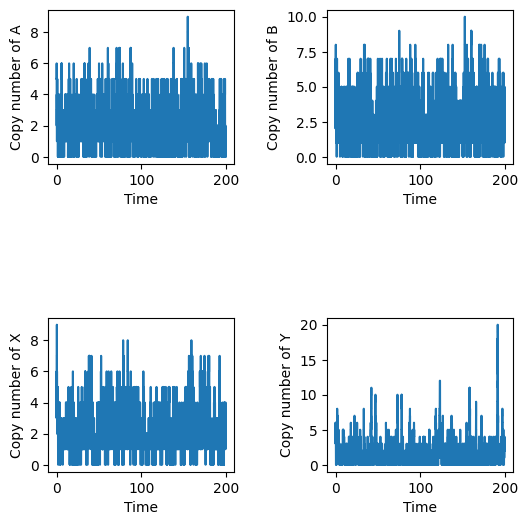

In [9]:
trajectory_file_new = "../data/example5_T200_trajectory.json"
time_list_new, state_list_new = load_trajectory(trajectory_file_new)
reactionNetwork.plot_trajectories(time_list_new, state_list_new)

time_list = time_list_new
state_list = state_list_new

# Parse trajectories for CRN1
print("Parsing Trajectory")
unique_states, jump_counts, waiting_times, propensities = parse_trajectory(
    state_list,time_list,reactant_matrix,unique_changes,compatible_reactions,verbose=True)
print("---------")

# Print basic summary
print("Finished parsing trajectories. Summary:")
print(f"Trajectory 1: {len(unique_states)} unique states observed")

In [10]:
# Ensure the results directory exists
results_dir = "../results/example5_T200"
os.makedirs(results_dir, exist_ok=True)

## Debugging Parameters
runOnlyHigherDim        = False   # Only try to run cases that have >=2 variables
runOnlyOneHigherDimCase = False  # Only run one case with >=2 variables for debugging

## MCMC parameters
NIterates = 500_000
Burnin    = 50_000
Thinout   = 100

# Loop over all unique stoichiometric changes
for index, deltaX in enumerate(unique_changes):
    
    print(f"\nProcessing Index: {index}, Stoichiometric Change: {deltaX}")

    # Extract local data for this stoichiometric change
    (local_counts, local_waiting_times, local_propensities, selected_deltaX) = extract_local_data(
        jump_counts, waiting_times, propensities, unique_changes, 
        index=index, deltaX=deltaX, verbose=True
    )

    # Extract local true theta
    localTheta = trueTheta[compatible_reactions[selected_deltaX]]
    num_reactions = len(localTheta)

    # Skip low-dimensional cases if debugging
    if num_reactions < 2 and runOnlyHigherDim:
        print(f"🚫 Index {index} skipped: only {num_reactions} reaction(s) — needs at least 2 to run MCMC.")
        continue

    # Compute 2-norm
    norm_theta = np.linalg.norm(localTheta, ord=2)
    print(f"Local True Theta: {localTheta} (Norm: {norm_theta:.4f})")

    # Compute likelihood for true theta
    likeTrue = local_log_likelihood(local_counts, local_waiting_times, local_propensities, localTheta)
    print(f"True Likelihood = {likeTrue}")

    total_count = sum(local_counts.values())
    print(f"Total Count = {total_count}")

    # Initialize theta for MCMC
    a, b = 0.001, 2.0
    theta_init = np.random.uniform(a, b, size=localTheta.shape)
    likeInit = local_log_likelihood(local_counts, local_waiting_times, local_propensities, theta_init)

    # Run adaptive MCMC only if norm is significant
    if norm_theta > 0.01:
        print(f"Running Adaptive MCMC with spike-and-slab prior...")
        
        filtered_reactions = [reaction_names[i] for i in compatible_reactions[selected_deltaX]]
        print(f"Reaction Names = {filtered_reactions}")

        AdaptiveThetaChain = adaptive_mcmc_spike_slab(
            local_counts, local_waiting_times, local_propensities,
            theta_init, trueTheta, num_iterations=NIterates,
            alpha=2, beta=0.25, pi=0.75, burn_in=Burnin, adapt_every_n=10,
            printEveryNSteps = 1000
        )

        # Define filenames
        filenameKDE = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_kde.png")
        filenameChain = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_chain.png")
        filenamePosterior = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_posterior.png")

        # Plotting
        plot_mcmc_samples(AdaptiveThetaChain, localTheta, epsilon=1e-5, burnin=Burnin, thinout=Thinout, filename=filenameKDE)
        plot_mcmc_chain(AdaptiveThetaChain, filename=filenameChain)
        if num_reactions >= 2:
            calc_network_posteriors(AdaptiveThetaChain, epsilon=1e-5, prob_cutoff=0.05, burnin=Burnin, thinout=Thinout)
            plot_network_and_parameter_posteriors(AdaptiveThetaChain, localTheta, epsilon=1e-5,
                                                 prob_cutoff=0.05, burnin=Burnin, thinout=Thinout, filename=filenamePosterior)

        # Summary statistics to Excel
        chains = [AdaptiveThetaChain]
        labels = ["Adaptive Spike & Slab"]
        summarize_chains(chains, localTheta, labels,
                         results_dir=results_dir, filename="mcmc_summary.xlsx",
                         burnin=Burnin, thinout=Thinout, alpha_ci=0.05, epsilon=1e-3,
                         run_index=index, count=total_count)

        print(f"MCMC completed for index {index}.")

        if (num_reactions > 1) and runOnlyOneHigherDimCase:
            break

    else:
        print(f"Skipping MCMC for index {index}: norm too small ({norm_theta:.4f}).")

    print("**********")



Processing Index: 0, Stoichiometric Change: (1, 0, 0, 0)
Extracting local data for stoichiometric change [1, 0, 0, 0] at index 0
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 1567 states processed.
Local True Theta: [0.         1.51680738 0.         0.         0.        ] (Norm: 1.5168)
True Likelihood = 116.56823291364846
Total Count = 512
Running Adaptive MCMC with spike-and-slab prior...
Reaction Names = ['Empty_to_A:', 'A_to_2A:', 'B_to_A+B:', 'X_to_A+X:', 'Y_to_A+Y:']
Iteration 1000: Accept Rate = 0.520, Theta = [0.         1.47519899 0.         0.         0.        ]
Iteration 2000: Accept Rate = 0.505, Theta = [0.        1.5690616 0.        0.        0.       ]
Iteration 3000: Accept Rate = 0.517, Theta = [0.         1.32116634 0.         0.         0.        ]
Iteration 4000: Accept Rate = 0.527, Theta = [0.         1.43894071 0.         0.         0.        ]
Iterat

/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:26: RuntimeWarning: invalid value encountered in divide
  acf = acf[n-1:] / acf[n-1]
/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:35: RuntimeWarning: invalid value encountered in scalar divide
  z = (np.mean(a) - np.mean(b)) / np.sqrt(np.var(a)/len(a) + np.var(b)/len(b))
/Users/suzanne/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Iteration 1000: Accept Rate = 0.467, Theta = [2.02746596 0.85526861 0.         0.         0.        ]
Iteration 2000: Accept Rate = 0.466, Theta = [0.         1.08770352 0.         0.75627201 0.        ]
Iteration 3000: Accept Rate = 0.419, Theta = [0.         1.08743194 0.         0.72025633 0.        ]
Iteration 4000: Accept Rate = 0.403, Theta = [0.         0.94698472 0.         0.7491096  0.        ]
Iteration 5000: Accept Rate = 0.392, Theta = [0.         1.1750072  0.         0.73856754 0.        ]
Iteration 6000: Accept Rate = 0.391, Theta = [0.         1.14433764 0.         0.77047784 0.        ]
Iteration 7000: Accept Rate = 0.383, Theta = [0.         1.03614876 0.         0.7125964  0.        ]
Iteration 8000: Accept Rate = 0.380, Theta = [0.         1.00079405 0.         0.73216004 0.        ]
Iteration 9000: Accept Rate = 0.376, Theta = [0.         0.92017213 0.         0.84012409 0.        ]
Iteration 10000: Accept Rate = 0.374, Theta = [0.         0.99269267 0.         0.

/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:26: RuntimeWarning: invalid value encountered in divide
  acf = acf[n-1:] / acf[n-1]
/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:35: RuntimeWarning: invalid value encountered in scalar divide
  z = (np.mean(a) - np.mean(b)) / np.sqrt(np.var(a)/len(a) + np.var(b)/len(b))
/Users/suzanne/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Iteration 1000: Accept Rate = 0.292, Theta = [0.6937603]
Iteration 2000: Accept Rate = 0.289, Theta = [0.57596898]
Iteration 3000: Accept Rate = 0.286, Theta = [0.64339049]
Iteration 4000: Accept Rate = 0.286, Theta = [0.60834533]
Iteration 5000: Accept Rate = 0.291, Theta = [0.66439714]
Iteration 6000: Accept Rate = 0.290, Theta = [0.64233839]
Iteration 7000: Accept Rate = 0.286, Theta = [0.66483748]
Iteration 8000: Accept Rate = 0.285, Theta = [0.71951098]
Iteration 9000: Accept Rate = 0.285, Theta = [0.61492633]
Iteration 10000: Accept Rate = 0.283, Theta = [0.75533203]
Iteration 11000: Accept Rate = 0.283, Theta = [0.62033327]
Iteration 12000: Accept Rate = 0.282, Theta = [0.58217582]
Iteration 13000: Accept Rate = 0.282, Theta = [0.66294349]
Iteration 14000: Accept Rate = 0.283, Theta = [0.51579789]
Iteration 15000: Accept Rate = 0.284, Theta = [0.64800735]
Iteration 16000: Accept Rate = 0.285, Theta = [0.577382]
Iteration 17000: Accept Rate = 0.284, Theta = [0.59442983]
Iteration

...

Iteration 1000: Accept Rate = 0.253, Theta = [0.         0.         0.35564173 0.         0.99509188]
Iteration 2000: Accept Rate = 0.241, Theta = [0.         0.         0.41632069 0.         0.92138902]
Iteration 3000: Accept Rate = 0.240, Theta = [0.         0.         0.44552625 0.         0.89350678]
Iteration 4000: Accept Rate = 0.235, Theta = [0.         0.         0.29809257 0.         0.99265584]
Iteration 5000: Accept Rate = 0.237, Theta = [0.         0.         0.36644369 0.         0.98839549]
Iteration 6000: Accept Rate = 0.239, Theta = [0.         0.         0.38794432 0.         0.99082128]
Iteration 7000: Accept Rate = 0.241, Theta = [0.         0.         0.32062282 0.         0.88153439]
Iteration 8000: Accept Rate = 0.244, Theta = [0.         0.         0.36964135 0.         0.97187856]
Iteration 9000: Accept Rate = 0.245, Theta = [0.         0.         0.28788544 0.         1.00604198]
Iteration 10000: Accept Rate = 0.249, Theta = [0.         0.         0.35976397 0.

/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:26: RuntimeWarning: invalid value encountered in divide
  acf = acf[n-1:] / acf[n-1]
/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:35: RuntimeWarning: invalid value encountered in scalar divide
  z = (np.mean(a) - np.mean(b)) / np.sqrt(np.var(a)/len(a) + np.var(b)/len(b))
/Users/suzanne/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Iteration 1000: Accept Rate = 0.385, Theta = [0.         0.         0.60965989 0.         0.        ]
Iteration 2000: Accept Rate = 0.390, Theta = [0.         0.         0.66195394 0.         0.        ]
Iteration 3000: Accept Rate = 0.390, Theta = [0.         0.         0.65673658 0.         0.        ]
Iteration 4000: Accept Rate = 0.399, Theta = [0.         0.         0.55653125 0.         0.        ]
Iteration 5000: Accept Rate = 0.400, Theta = [0.         0.         0.68813115 0.         0.        ]
Iteration 6000: Accept Rate = 0.395, Theta = [0.         0.         0.62579627 0.         0.        ]
Iteration 7000: Accept Rate = 0.390, Theta = [0.         0.         0.60252705 0.         0.        ]
Iteration 8000: Accept Rate = 0.391, Theta = [0.        0.        0.6505705 0.        0.       ]
Iteration 9000: Accept Rate = 0.389, Theta = [0.        0.        0.6833302 0.        0.       ]
Iteration 10000: Accept Rate = 0.388, Theta = [0.         0.         0.64424001 0.         0

/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:26: RuntimeWarning: invalid value encountered in divide
  acf = acf[n-1:] / acf[n-1]
/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:35: RuntimeWarning: invalid value encountered in scalar divide
  z = (np.mean(a) - np.mean(b)) / np.sqrt(np.var(a)/len(a) + np.var(b)/len(b))
/Users/suzanne/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Skipping MCMC for index 53: norm too small (0.0000).
**********

Processing Index: 54, Stoichiometric Change: (-2, 0, 0, 0)
Extracting local data for stoichiometric change [-2, 0, 0, 0] at index 54
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 1567 states processed.
Local True Theta: [0.45275681] (Norm: 0.4528)
True Likelihood = -66.89159994811482
Total Count = 115
Running Adaptive MCMC with spike-and-slab prior...
Reaction Names = ['2A_to_Empty:']
Iteration 1000: Accept Rate = 0.195, Theta = [0.42747051]
Iteration 2000: Accept Rate = 0.210, Theta = [0.47276705]
Iteration 3000: Accept Rate = 0.206, Theta = [0.44255336]
Iteration 4000: Accept Rate = 0.209, Theta = [0.4219562]
Iteration 5000: Accept Rate = 0.208, Theta = [0.39082847]
Iteration 6000: Accept Rate = 0.205, Theta = [0.45538069]
Iteration 7000: Accept Rate = 0.203, Theta = [0.36956163]
Iteration 8000: Accept Rate = 

## Parsing Trajectory 3 (TFinal = 400)

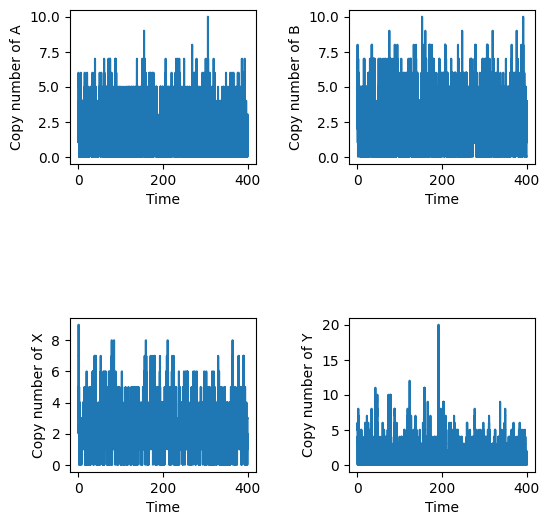

In [11]:
trajectory_file_new = "../data/example5_T400_trajectory.json"
time_list_new, state_list_new = load_trajectory(trajectory_file_new)
reactionNetwork.plot_trajectories(time_list_new, state_list_new)

time_list = time_list_new
state_list = state_list_new

In [12]:
# Parse trajectories for CRN1
print("Parsing Trajectory")
unique_states, jump_counts, waiting_times, propensities = parse_trajectory(
    state_list,time_list,reactant_matrix,unique_changes,compatible_reactions,verbose=True)
print("---------")

# Print basic summary
print("Finished parsing trajectories. Summary:")
print(f"Trajectory 3: {len(unique_states)} unique states observed")

Parsing Trajectory
Tracking 130 unique stoichiometric changes.
Trajectory length: 16117 timepoints. Iterating to len-2 to avoid final non-jump.
Finished parsing trajectory. Observed 1887 unique states.
---------
Finished parsing trajectories. Summary:
Trajectory 3: 1887 unique states observed


In [13]:
# Ensure the results directory exists
results_dir = "../results/example5_T400"
os.makedirs(results_dir, exist_ok=True)

## Debugging Parameters
runOnlyHigherDim        = False   # Only try to run cases that have >=2 variables
runOnlyOneHigherDimCase = False  # Only run one case with >=2 variables for debugging

## MCMC parameters
NIterates = 500_000
Burnin    = 50_000
Thinout   = 100


# Loop over all unique stoichiometric changes
for index, deltaX in enumerate(unique_changes):
    
    print(f"\nProcessing Index: {index}, Stoichiometric Change: {deltaX}")

    # Extract local data for this stoichiometric change
    (local_counts, local_waiting_times, local_propensities, selected_deltaX) = extract_local_data(
        jump_counts, waiting_times, propensities, unique_changes, 
        index=index, deltaX=deltaX, verbose=True
    )

    # Extract local true theta
    localTheta = trueTheta[compatible_reactions[selected_deltaX]]
    num_reactions = len(localTheta)

    # Skip low-dimensional cases if debugging
    if num_reactions < 2 and runOnlyHigherDim:
        print(f"🚫 Index {index} skipped: only {num_reactions} reaction(s) — needs at least 2 to run MCMC.")
        continue

    # Compute 2-norm
    norm_theta = np.linalg.norm(localTheta, ord=2)
    print(f"Local True Theta: {localTheta} (Norm: {norm_theta:.4f})")

    # Compute likelihood for true theta
    likeTrue = local_log_likelihood(local_counts, local_waiting_times, local_propensities, localTheta)
    print(f"True Likelihood = {likeTrue}")

    total_count = sum(local_counts.values())
    print(f"Total Count = {total_count}")

    # Initialize theta for MCMC
    a, b = 0.001, 2.0
    theta_init = np.random.uniform(a, b, size=localTheta.shape)
    likeInit = local_log_likelihood(local_counts, local_waiting_times, local_propensities, theta_init)

    # Run adaptive MCMC only if norm is significant
    if norm_theta > 0.01:
        print(f"Running Adaptive MCMC with spike-and-slab prior...")
        
        filtered_reactions = [reaction_names[i] for i in compatible_reactions[selected_deltaX]]
        print(f"Reaction Names = {filtered_reactions}")

        AdaptiveThetaChain = adaptive_mcmc_spike_slab(
            local_counts, local_waiting_times, local_propensities,
            theta_init, trueTheta, num_iterations=NIterates,
            alpha=2, beta=0.25, pi=0.75, burn_in=Burnin, adapt_every_n=10,
            printEveryNSteps = 1000
        )

        # Define filenames
        filenameKDE = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_kde.png")
        filenameChain = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_chain.png")
        filenamePosterior = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_posterior.png")

        # Plotting
        plot_mcmc_samples(AdaptiveThetaChain, localTheta, epsilon=1e-5, burnin=Burnin, thinout=Thinout, filename=filenameKDE)
        plot_mcmc_chain(AdaptiveThetaChain, filename=filenameChain)
        if num_reactions >= 2:
            calc_network_posteriors(AdaptiveThetaChain, epsilon=1e-5, prob_cutoff=0.05, burnin=Burnin, thinout=Thinout)
            plot_network_and_parameter_posteriors(AdaptiveThetaChain, localTheta, epsilon=1e-5,
                                                 prob_cutoff=0.05, burnin=Burnin, thinout=Thinout, filename=filenamePosterior)

        # Summary statistics to Excel
        chains = [AdaptiveThetaChain]
        labels = ["Adaptive Spike & Slab"]
        summarize_chains(chains, localTheta, labels,
                         results_dir=results_dir, filename="mcmc_summary.xlsx",
                         burnin=Burnin, thinout=Thinout, alpha_ci=0.05, epsilon=1e-3,
                         run_index=index, count=total_count)

        print(f"MCMC completed for index {index}.")

        if (num_reactions > 1) and runOnlyOneHigherDimCase:
            break

    else:
        print(f"Skipping MCMC for index {index}: norm too small ({norm_theta:.4f}).")

    print("**********")



Processing Index: 0, Stoichiometric Change: (1, 0, 0, 0)
Extracting local data for stoichiometric change [1, 0, 0, 0] at index 0
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 1887 states processed.
Local True Theta: [0.         1.51680738 0.         0.         0.        ] (Norm: 1.5168)
True Likelihood = 297.1564616043068
Total Count = 1054
Running Adaptive MCMC with spike-and-slab prior...
Reaction Names = ['Empty_to_A:', 'A_to_2A:', 'B_to_A+B:', 'X_to_A+X:', 'Y_to_A+Y:']
Iteration 1000: Accept Rate = 0.392, Theta = [0.         1.54368744 0.         0.         0.        ]
Iteration 2000: Accept Rate = 0.408, Theta = [0.         1.47515946 0.         0.         0.        ]
Iteration 3000: Accept Rate = 0.425, Theta = [0.         1.56525785 0.         0.         0.        ]
Iteration 4000: Accept Rate = 0.431, Theta = [0.         1.56346981 0.         0.         0.        ]
I

/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:26: RuntimeWarning: invalid value encountered in divide
  acf = acf[n-1:] / acf[n-1]
/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:35: RuntimeWarning: invalid value encountered in scalar divide
  z = (np.mean(a) - np.mean(b)) / np.sqrt(np.var(a)/len(a) + np.var(b)/len(b))
/Users/suzanne/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Iteration 1000: Accept Rate = 0.217, Theta = [0.         1.04488295 0.         0.82615317 0.        ]
Iteration 2000: Accept Rate = 0.226, Theta = [0.         1.03158911 0.         0.79180069 0.        ]
Iteration 3000: Accept Rate = 0.222, Theta = [0.         1.0234465  0.         0.67703447 0.        ]
Iteration 4000: Accept Rate = 0.223, Theta = [0.         1.00615899 0.         0.84390781 0.        ]
Iteration 5000: Accept Rate = 0.226, Theta = [0.         1.03648326 0.         0.7789342  0.        ]
Iteration 6000: Accept Rate = 0.235, Theta = [0.         1.03183512 0.         0.81100487 0.        ]
Iteration 7000: Accept Rate = 0.238, Theta = [0.         1.10954832 0.         0.7368782  0.        ]
Iteration 8000: Accept Rate = 0.239, Theta = [0.         1.05566747 0.         0.71966225 0.        ]
Iteration 9000: Accept Rate = 0.244, Theta = [0.         0.96909088 0.         0.86868034 0.        ]
Iteration 10000: Accept Rate = 0.242, Theta = [0.         1.01954047 0.         0.

/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:26: RuntimeWarning: invalid value encountered in divide
  acf = acf[n-1:] / acf[n-1]
/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:35: RuntimeWarning: invalid value encountered in scalar divide
  z = (np.mean(a) - np.mean(b)) / np.sqrt(np.var(a)/len(a) + np.var(b)/len(b))
/Users/suzanne/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Iteration 1000: Accept Rate = 0.224, Theta = [0.60933369]
Iteration 2000: Accept Rate = 0.213, Theta = [0.65448974]
Iteration 3000: Accept Rate = 0.210, Theta = [0.58255935]
Iteration 4000: Accept Rate = 0.216, Theta = [0.66519893]
Iteration 5000: Accept Rate = 0.215, Theta = [0.57247242]
Iteration 6000: Accept Rate = 0.209, Theta = [0.63153043]
Iteration 7000: Accept Rate = 0.211, Theta = [0.63377774]
Iteration 8000: Accept Rate = 0.209, Theta = [0.60692467]
Iteration 9000: Accept Rate = 0.206, Theta = [0.5842192]
Iteration 10000: Accept Rate = 0.206, Theta = [0.65021855]
Iteration 11000: Accept Rate = 0.205, Theta = [0.63337174]
Iteration 12000: Accept Rate = 0.204, Theta = [0.61293556]
Iteration 13000: Accept Rate = 0.206, Theta = [0.60070101]
Iteration 14000: Accept Rate = 0.206, Theta = [0.59072951]
Iteration 15000: Accept Rate = 0.205, Theta = [0.62970662]
Iteration 16000: Accept Rate = 0.206, Theta = [0.60523705]
Iteration 17000: Accept Rate = 0.206, Theta = [0.69004479]
Iterati

...

Iteration 1000: Accept Rate = 0.255, Theta = [0.51116751 0.         0.         0.         0.97425842]
Iteration 2000: Accept Rate = 0.245, Theta = [0.47156556 0.         0.         0.         0.99102485]
Iteration 3000: Accept Rate = 0.235, Theta = [0.57100763 0.         0.         0.         0.92457651]
Iteration 4000: Accept Rate = 0.231, Theta = [0.37928229 0.         0.         0.         1.11279348]
Iteration 5000: Accept Rate = 0.230, Theta = [0.41705539 0.         0.         0.         0.99555668]
Iteration 6000: Accept Rate = 0.228, Theta = [0.41910859 0.         0.         0.         0.96585158]
Iteration 7000: Accept Rate = 0.226, Theta = [0.43521325 0.         0.         0.         1.00940953]
Iteration 8000: Accept Rate = 0.225, Theta = [0.48528352 0.         0.         0.         1.01137377]
Iteration 9000: Accept Rate = 0.222, Theta = [0.42079711 0.         0.         0.         0.97296059]
Iteration 10000: Accept Rate = 0.225, Theta = [0.46520127 0.         0.         0.

/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:26: RuntimeWarning: invalid value encountered in divide
  acf = acf[n-1:] / acf[n-1]
/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:35: RuntimeWarning: invalid value encountered in scalar divide
  z = (np.mean(a) - np.mean(b)) / np.sqrt(np.var(a)/len(a) + np.var(b)/len(b))
/Users/suzanne/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Iteration 1000: Accept Rate = 0.306, Theta = [0.         0.         0.65931553 0.         0.        ]
Iteration 2000: Accept Rate = 0.318, Theta = [0.         0.         0.63368323 0.         0.        ]
Iteration 3000: Accept Rate = 0.320, Theta = [0.         0.         0.68897224 0.         0.        ]
Iteration 4000: Accept Rate = 0.324, Theta = [0.         0.         0.65536532 0.         0.        ]
Iteration 5000: Accept Rate = 0.330, Theta = [0.         0.         0.64356373 0.         0.        ]
Iteration 6000: Accept Rate = 0.324, Theta = [0.         0.         0.67324345 0.         0.        ]
Iteration 7000: Accept Rate = 0.325, Theta = [0.         0.         0.69404514 0.         0.        ]
Iteration 8000: Accept Rate = 0.320, Theta = [0.         0.         0.63166186 0.         0.        ]
Iteration 9000: Accept Rate = 0.312, Theta = [0.         0.         0.66653118 0.         0.        ]
Iteration 10000: Accept Rate = 0.310, Theta = [0.         0.         0.70636314 0.

/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:26: RuntimeWarning: invalid value encountered in divide
  acf = acf[n-1:] / acf[n-1]
/Users/suzanne/Documents/GitHub/BayesCRNInference/src/mcmc.py:35: RuntimeWarning: invalid value encountered in scalar divide
  z = (np.mean(a) - np.mean(b)) / np.sqrt(np.var(a)/len(a) + np.var(b)/len(b))
/Users/suzanne/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Run 47 | Adaptive Spike & Slab: L2 error of mean from true theta = 0.01987
Saving summary to: ../results/example5_T400/mcmc_summary.xlsx
Summary saved successfully.
MCMC completed for index 47.
**********

Processing Index: 48, Stoichiometric Change: (2, 0, 0, -1)
Extracting local data for stoichiometric change [2, 0, 0, -1] at index 48
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 1887 states processed.
Local True Theta: [0.] (Norm: 0.0000)
True Likelihood = 0
Total Count = 0
Skipping MCMC for index 48: norm too small (0.0000).
**********

Processing Index: 49, Stoichiometric Change: (0, 2, 0, -1)
Extracting local data for stoichiometric change [0, 2, 0, -1] at index 49
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 1887 states processed.
Local True Theta: [0.] (Nor